# Notebook 3 — Balanço Patrimonial com Hierarquia

**Objetivo:** Extrair o BP da Silver consolidada, reconstruir a hierarquia pai-filho (Safe Mode V11), validar a equação fundamental (Ativo = Passivo + PL) e escrever a tabela curada.  
**Input:** `layer_02_silver.n0_dfp_cia_aberta`  
**Output:** `layer_02_silver.n1_dfp_cia_aberta_bp`

## 1. Importando Bibliotecas

In [2]:
import pandas as pd
import datetime
import logging
import os
import numpy as np
from sqlalchemy import create_engine, text, inspect
from urllib.parse import quote_plus
from dotenv import load_dotenv

In [3]:
# Carrega variáveis de ambiente
load_dotenv()

True

In [4]:
# Definindo a função para criar a engine do banco de dados
def create_db_engine():
        user = quote_plus(os.getenv('DB_USER', 'postgres'))
        password = quote_plus(os.getenv('DB_PASS', 'password'))
        host = os.getenv('DB_HOST', 'localhost')
        port = os.getenv('DB_PORT', '5432')
        dbname = os.getenv('DB_NAME', 'data_lake')
        
        connection_str = f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}"
        return create_engine(connection_str)

In [5]:
# Efetivamente criando a engine
engine = create_db_engine()

## 2. Query de Extração do BP — deduplicação por versão e IS_LEAF da Silver

> A query parte de `n0_dfp_cia_aberta` (já normalizada) e aplica `ROW_NUMBER()` para garantir  
> apenas a versão mais recente por empresa/período/conta.

In [6]:
query_bp_hierarquias = '''
WITH base_bruta AS (
    SELECT 
        *,
        ROW_NUMBER() OVER(
            PARTITION BY "CNPJ_CIA", "DT_REFER", "CD_CONTA", "DS_CONTA", "VL_CONTA_TRATADO"
            ORDER BY "VERSAO" DESC
        ) as rn
    FROM layer_02_silver.n0_dfp_cia_aberta
    WHERE "GRUPO_DFP_TRATADO" = 'BP'
),
base_deduplicada AS (
    SELECT * FROM base_bruta WHERE rn = 1
),
base_hierarquia AS (
    SELECT 
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 1) as "CHAVE_BUSCA_NIVEL_1",
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 3) as "CHAVE_BUSCA_NIVEL_2",
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 5) as "CHAVE_BUSCA_NIVEL_3",
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 7) as "CHAVE_BUSCA_NIVEL_4",
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 9) as "CHAVE_BUSCA_NIVEL_5",
        t.*
    FROM base_deduplicada t
),
ref_nivel_1 as (
    SELECT DISTINCT ON ("CHAVE_MATCH")
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 1) as "CHAVE_MATCH",
        UPPER(TRIM("DS_CONTA")) as "DS_NIVEL_1"
    FROM layer_02_silver.n0_dfp_cia_aberta WHERE "GRUPO_DFP_TRATADO" = 'BP' AND "CD_CONTA_QTD_DIGITOS" = 1
    ORDER BY "CHAVE_MATCH", "VERSAO" DESC
),
ref_nivel_2 as (
    SELECT DISTINCT ON ("CHAVE_MATCH")
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 3) as "CHAVE_MATCH",
        UPPER(TRIM("DS_CONTA")) as "DS_NIVEL_2"
    FROM layer_02_silver.n0_dfp_cia_aberta WHERE "GRUPO_DFP_TRATADO" = 'BP' AND "CD_CONTA_QTD_DIGITOS" = 3
    ORDER BY "CHAVE_MATCH", "VERSAO" DESC
),
ref_nivel_3 as (
    SELECT DISTINCT ON ("CHAVE_MATCH")
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 5) as "CHAVE_MATCH",
        UPPER(TRIM("DS_CONTA")) as "DS_NIVEL_3"
    FROM layer_02_silver.n0_dfp_cia_aberta WHERE "GRUPO_DFP_TRATADO" = 'BP' AND "CD_CONTA_QTD_DIGITOS" = 5
    ORDER BY "CHAVE_MATCH", "VERSAO" DESC
),
ref_nivel_4 as (
    SELECT DISTINCT ON ("CHAVE_MATCH")
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 7) as "CHAVE_MATCH",
        UPPER(TRIM("DS_CONTA")) as "DS_NIVEL_4"
    FROM layer_02_silver.n0_dfp_cia_aberta WHERE "GRUPO_DFP_TRATADO" = 'BP' AND "CD_CONTA_QTD_DIGITOS" = 7
    ORDER BY "CHAVE_MATCH", "VERSAO" DESC
),
ref_nivel_5 as (
    SELECT DISTINCT ON ("CHAVE_MATCH")
        "CNPJ_CIA" || "DT_REFER" || "GRUPO_DFP_TRATADO" || left(REPLACE("CD_CONTA", '.',''), 9) as "CHAVE_MATCH",
        UPPER(TRIM("DS_CONTA")) as "DS_NIVEL_5"
    FROM layer_02_silver.n0_dfp_cia_aberta WHERE "GRUPO_DFP_TRATADO" = 'BP' AND "CD_CONTA_QTD_DIGITOS" = 9
    ORDER BY "CHAVE_MATCH", "VERSAO" DESC
)
SELECT 
    base."CNPJ_CIA",
    empresas_selecionadas."SETOR_ATIV",
    base."DT_REFER",
    base."DT_REFER_TRATADO", base."DT_REFER_ANO", base."VERSAO", base."DENOM_CIA", base."CD_CVM",  
    base."GRUPO_DFP_TRATADO", base."DT_FIM_EXERC_TRATADO", base."DT_FIM_EXERC_ANO", 
    base."CD_CONTA", base."CD_CONTA_QTD_DIGITOS", base."DS_CONTA",
    
    -- [AJUSTE AQUI] Adicionado para padronizar com DFC/DRE
    base."CD_CONTA" || ' - ' || base."DS_CONTA" as "CONTA_NOME_COMPLETO",
    
    base."VL_CONTA_TRATADO", base."ST_CONTA_FIXA", base."IS_LEAF",
    COALESCE(n1."DS_NIVEL_1", CASE WHEN left(base."CD_CONTA",1)='1' THEN 'ATIVO TOTAL' ELSE 'PASSIVO TOTAL' END) as "DS_NIVEL_1",
    n2."DS_NIVEL_2", n3."DS_NIVEL_3", n4."DS_NIVEL_4", n5."DS_NIVEL_5",
    'layer_02_silver.n0_dfp_cia_aberta' as "_origem_tabela"
FROM base_hierarquia base
LEFT JOIN ref_nivel_1 n1 ON base."CHAVE_BUSCA_NIVEL_1" = n1."CHAVE_MATCH"
LEFT JOIN ref_nivel_2 n2 ON base."CHAVE_BUSCA_NIVEL_2" = n2."CHAVE_MATCH"
LEFT JOIN ref_nivel_3 n3 ON base."CHAVE_BUSCA_NIVEL_3" = n3."CHAVE_MATCH"
LEFT JOIN ref_nivel_4 n4 ON base."CHAVE_BUSCA_NIVEL_4" = n4."CHAVE_MATCH"
LEFT JOIN ref_nivel_5 n5 ON base."CHAVE_BUSCA_NIVEL_5" = n5."CHAVE_MATCH"
LEFT JOIN layer_02_silver.n0_empresas_selecionadas as empresas_selecionadas
            ON base."CNPJ_CIA" = empresas_selecionadas."CNPJ_CIA"
ORDER BY base."CNPJ_CIA", base."DT_REFER", base."CD_CONTA";
'''

## 3. Extração dos Dados

In [7]:
# 1. Extração e Consolidação em Memória
with engine.connect() as conn:
    df_bp = pd.read_sql(
        text(query_bp_hierarquias), 
        con=conn
    )

In [8]:
df_bp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180438 entries, 0 to 180437
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CNPJ_CIA              180438 non-null  object 
 1   SETOR_ATIV            180438 non-null  object 
 2   DT_REFER              180438 non-null  object 
 3   DT_REFER_TRATADO      180438 non-null  object 
 4   DT_REFER_ANO          180438 non-null  float64
 5   VERSAO                180438 non-null  object 
 6   DENOM_CIA             180438 non-null  object 
 7   CD_CVM                180438 non-null  object 
 8   GRUPO_DFP_TRATADO     180438 non-null  object 
 9   DT_FIM_EXERC_TRATADO  180438 non-null  object 
 10  DT_FIM_EXERC_ANO      180438 non-null  float64
 11  CD_CONTA              180438 non-null  object 
 12  CD_CONTA_QTD_DIGITOS  180438 non-null  int64  
 13  DS_CONTA              180438 non-null  object 
 14  CONTA_NOME_COMPLETO   180438 non-null  object 
 15  

In [9]:
df_bp.query("DENOM_CIA=='HAPVIDA PARTICIPAÇÕES E INVESTIMENTOS S.A.'").query("DS_CONTA=='Ativo Total'").query("DT_REFER=='2019-12-31'").to_dict()

{'CNPJ_CIA': {25882: '05.197.443/0001-38'},
 'SETOR_ATIV': {25882: 'Serviços Médicos'},
 'DT_REFER': {25882: '2019-12-31'},
 'DT_REFER_TRATADO': {25882: datetime.date(2019, 12, 31)},
 'DT_REFER_ANO': {25882: 2019.0},
 'VERSAO': {25882: '1'},
 'DENOM_CIA': {25882: 'HAPVIDA PARTICIPAÇÕES E INVESTIMENTOS S.A.'},
 'CD_CVM': {25882: '24392'},
 'GRUPO_DFP_TRATADO': {25882: 'BP'},
 'DT_FIM_EXERC_TRATADO': {25882: datetime.date(2019, 12, 31)},
 'DT_FIM_EXERC_ANO': {25882: 2019.0},
 'CD_CONTA': {25882: '1'},
 'CD_CONTA_QTD_DIGITOS': {25882: 1},
 'DS_CONTA': {25882: 'Ativo Total'},
 'CONTA_NOME_COMPLETO': {25882: '1 - Ativo Total'},
 'VL_CONTA_TRATADO': {25882: 12453686000.0},
 'ST_CONTA_FIXA': {25882: 'S'},
 'IS_LEAF': {25882: False},
 'DS_NIVEL_1': {25882: 'ATIVO TOTAL'},
 'DS_NIVEL_2': {25882: None},
 'DS_NIVEL_3': {25882: None},
 'DS_NIVEL_4': {25882: None},
 'DS_NIVEL_5': {25882: None},
 '_origem_tabela': {25882: 'layer_02_silver.n0_dfp_cia_aberta'}}

## 4. Histórico de Desenvolvimento — raciocínio iterativo do pipeline

> Esta seção documenta as iterações que levaram ao pipeline final.  
> Mantida para fins pedagógicos: mostra como o problema foi sendo descoberto e resolvido incrementalmente.

In [10]:
# 1. Cria a pivot table
df_pivot = df_bp.query("IS_LEAF==True").pivot_table(
    values='VL_CONTA_TRATADO', 
    index=['CNPJ_CIA','DENOM_CIA', 'DT_REFER'], 
    columns='DS_NIVEL_1', 
    aggfunc='sum', 
    fill_value=0
)

# 2. Flatten (Reseta o índice para virar coluna)
df_flat = df_pivot.reset_index()

# 3. (Opcional) Remove o nome "DS_NIVEL_1" do cabeçalho das colunas para ficar estético
df_flat.columns.name = None

df_flat['DIFERENCA'] = df_flat['ATIVO TOTAL'] - df_flat['PASSIVO TOTAL']
df_flat['STATUS'] = np.where(df_flat['DIFERENCA'].abs() > 0.1, 'ERRO', 'OK')

# Ordenar pelos erros
df_final = df_flat.sort_values(by='DIFERENCA', key=abs, ascending=False)

In [11]:
# A linha abaixo filtra apenas os registros com erro de forma que possamos analisar melhor se algum balanço de alguma empresa não esteja fechando corretamente
df_final.query("STATUS=='ERRO'")

,CNPJ_CIA,DENOM_CIA,DT_REFER,ATIVO TOTAL,PASSIVO TOTAL,DIFERENCA,STATUS


Realmente as Lojas Renner divulgaram a conta analítica 2.01.03.01.02 - Demais Obrigações Federais sem estar arredondada, ou seja, com 47 "centavos". E isso foi pro arquivo da CVM de 31-12-2024, conforme print abaixo. Para sanar foi usada a regra de truncar os números e aí a equação básica da Contabilidade bateu novamente.

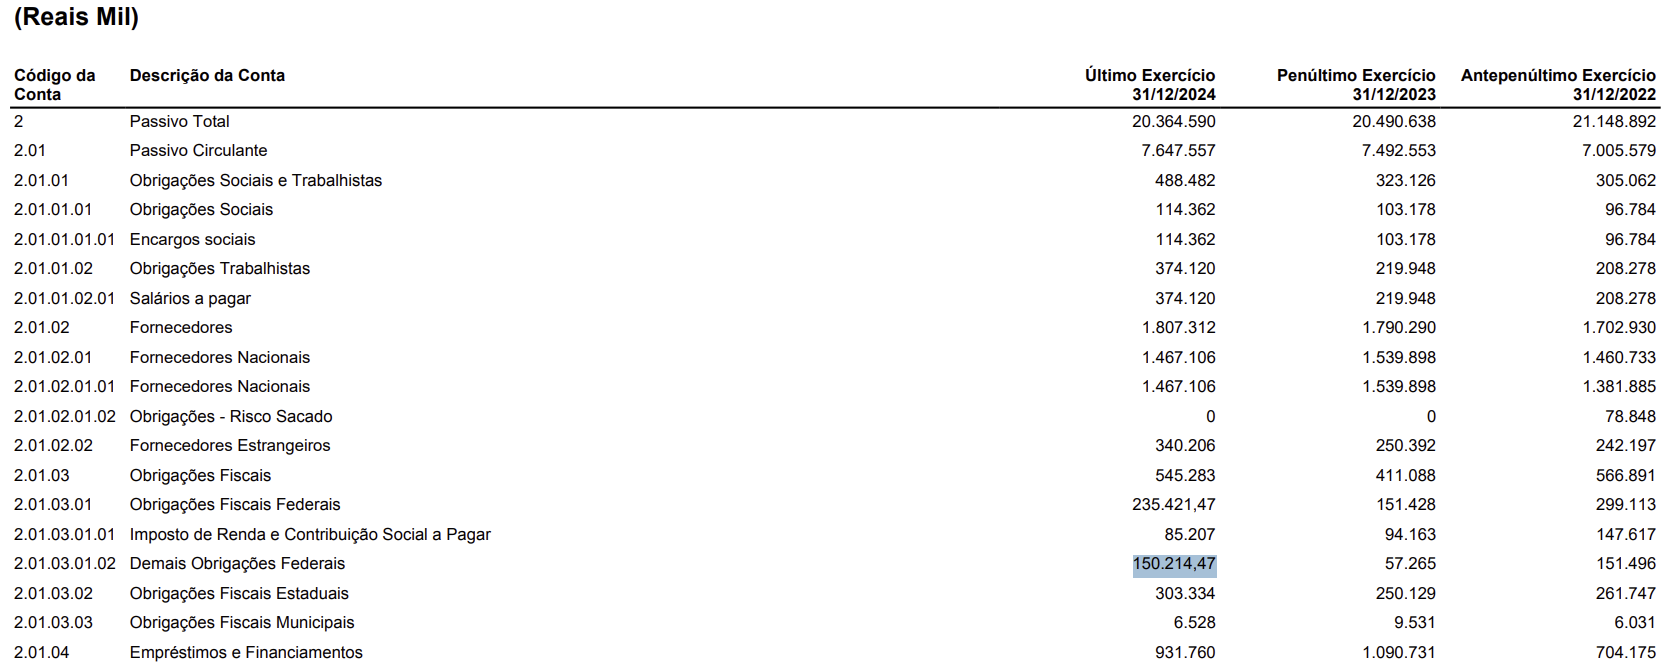

In [12]:
# Exemplo dos dados do ativo para as Lojas Renner em  formato de Série Temporal
df_bp.query("IS_LEAF==True")\
        .query("CNPJ_CIA=='92.754.738/0001-62'")\
        .query("DS_NIVEL_1=='ATIVO TOTAL'")\
        .pivot_table(
            values='VL_CONTA_TRATADO', 
            index=['CNPJ_CIA','DENOM_CIA','DS_NIVEL_1','DS_NIVEL_2', 'DS_NIVEL_3'], 
            columns='DT_REFER', 
            aggfunc='sum', 
            fill_value=0
        )\
        .reset_index()

DT_REFER,CNPJ_CIA,DENOM_CIA,DS_NIVEL_1,DS_NIVEL_2,DS_NIVEL_3,2010-12-31,2011-12-31,2012-12-31,2013-12-31,2014-12-31,2015-12-31,2016-12-31,2017-12-31,2018-12-31,2019-12-31,2020-12-31,2021-12-31,2022-12-31,2023-12-31,2024-12-31
0,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO CIRCULANTE,APLICAÇÕES FINANCEIRAS,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.236000e+07,4.396930e+08,2.242490e+08,6.055720e+08,4.580850e+08,6.551310e+08,5.716550e+08,8.451970e+08
1,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO CIRCULANTE,CAIXA E EQUIVALENTES DE CAIXA,683661000.0,5.782640e+08,6.832700e+08,8.015920e+08,8.343400e+08,7.375270e+08,8.948810e+08,1.059873e+09,9.446710e+08,1.148053e+09,2.066781e+09,5.489417e+09,2.848351e+09,2.532187e+09,1.926110e+09
2,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO CIRCULANTE,CONTAS A RECEBER,893748000.0,1.022451e+09,1.310155e+09,1.621130e+09,1.981179e+09,2.268184e+09,2.266291e+09,2.696993e+09,3.162670e+09,3.825961e+09,3.811668e+09,5.412881e+09,6.524832e+09,6.639188e+09,6.902933e+09
3,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO CIRCULANTE,DESPESAS ANTECIPADAS,952000.0,1.647000e+06,1.856000e+06,3.176000e+06,3.397000e+06,5.336000e+06,6.198000e+06,5.266000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO CIRCULANTE,ESTOQUES,275950000.0,4.027480e+08,4.540110e+08,5.069900e+08,6.123000e+08,6.225340e+08,7.822660e+08,9.231760e+08,1.110305e+09,1.124506e+09,1.381662e+09,1.609560e+09,1.836947e+09,1.774209e+09,1.929908e+09
5,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO CIRCULANTE,OUTROS ATIVOS CIRCULANTES,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.415600e+07,7.504400e+07,6.908600e+07,1.654480e+08,1.846600e+08,1.282330e+08,1.342770e+08
6,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO CIRCULANTE,TRIBUTOS A RECUPERAR,18610000.0,3.044500e+07,4.759800e+07,6.837400e+07,6.812700e+07,8.763000e+07,1.358410e+08,1.402730e+08,2.088400e+08,2.583960e+08,9.619970e+08,8.493890e+08,1.003849e+09,5.461720e+08,5.782340e+08
7,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO NÃO CIRCULANTE,ATIVO REALIZÁVEL A LONGO PRAZO,103451000.0,1.435470e+08,1.707060e+08,1.286480e+08,1.499850e+08,1.764460e+08,2.443760e+08,2.998090e+08,2.611880e+08,2.976200e+08,9.508830e+08,1.134518e+09,1.015666e+09,1.284444e+09,1.224934e+09
8,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO NÃO CIRCULANTE,IMOBILIZADO,412603000.0,5.994810e+08,8.462040e+08,1.063348e+09,1.304065e+09,1.545704e+09,1.645069e+09,1.813627e+09,1.994449e+09,4.053671e+09,3.854298e+09,5.085047e+09,5.440289e+09,5.286353e+09,5.152988e+09
9,92.754.738/0001-62,LOJAS RENNER S.A.,ATIVO TOTAL,ATIVO NÃO CIRCULANTE,INTANGÍVEL,66977000.0,2.048580e+08,2.561650e+08,3.222030e+08,3.680840e+08,4.202950e+08,5.002440e+08,5.262350e+08,6.350760e+08,7.842350e+08,9.406360e+08,1.207640e+09,1.639167e+09,1.702201e+09,1.613427e+09


In [13]:
# Exemplo dos dados do passivo para as Lojas Renner em formato de Série Temporal
df_bp.query("IS_LEAF==True")\
        .query("CNPJ_CIA=='92.754.738/0001-62'")\
        .query("DS_NIVEL_1=='PASSIVO TOTAL'")\
        .pivot_table(
            values='VL_CONTA_TRATADO', 
            index=['CNPJ_CIA','DENOM_CIA','DS_NIVEL_1','DS_NIVEL_2', 'DS_NIVEL_3'], 
            columns='DT_REFER', 
            aggfunc='sum', 
            fill_value=0
        )\
        .reset_index()

DT_REFER,CNPJ_CIA,DENOM_CIA,DS_NIVEL_1,DS_NIVEL_2,DS_NIVEL_3,2010-12-31,2011-12-31,2012-12-31,2013-12-31,2014-12-31,2015-12-31,2016-12-31,2017-12-31,2018-12-31,2019-12-31,2020-12-31,2021-12-31,2022-12-31,2023-12-31,2024-12-31
0,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO CIRCULANTE,EMPRÉSTIMOS E FINANCIAMENTOS,279426000.0,172159000.0,670248000.0,7.355990e+08,5.595370e+08,7.065890e+08,9.961710e+08,5.168390e+08,1.423835e+09,8.940180e+08,1.418471e+09,2.085974e+09,7.041750e+08,1.090731e+09,9.317600e+08
1,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO CIRCULANTE,FORNECEDORES,318285000.0,429887000.0,456484000.0,4.713840e+08,5.614800e+08,5.534530e+08,6.797210e+08,8.422540e+08,9.558340e+08,1.082399e+09,1.404852e+09,1.762233e+09,1.702930e+09,1.790290e+09,1.807312e+09
2,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO CIRCULANTE,OBRIGAÇÕES FISCAIS,146674000.0,211273000.0,244089000.0,2.548980e+08,3.205820e+08,3.429760e+08,4.047600e+08,4.709890e+08,5.500160e+08,6.367230e+08,4.029300e+08,5.166780e+08,5.668910e+08,4.110880e+08,5.452830e+08
3,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO CIRCULANTE,OBRIGAÇÕES SOCIAIS E TRABALHISTAS,72108000.0,67001000.0,103317000.0,1.019440e+08,1.420150e+08,1.747040e+08,1.794700e+08,2.333380e+08,2.460090e+08,3.068820e+08,2.268160e+08,4.603730e+08,3.050620e+08,3.231260e+08,4.884820e+08
4,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO CIRCULANTE,OUTRAS OBRIGAÇÕES,143501000.0,166131000.0,232315000.0,3.512710e+08,4.297500e+08,5.115390e+08,6.239730e+08,8.422960e+08,1.100878e+09,1.780740e+09,2.113283e+09,3.062229e+09,3.641442e+09,3.780492e+09,3.784683e+09
5,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO CIRCULANTE,PROVISÕES,17581000.0,19124000.0,18759000.0,1.749300e+07,2.399800e+07,2.986600e+07,3.365600e+07,3.599600e+07,4.778300e+07,6.763500e+07,6.705900e+07,6.661300e+07,8.507900e+07,9.682600e+07,9.003700e+07
6,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO NÃO CIRCULANTE,EMPRÉSTIMOS E FINANCIAMENTOS,377076000.0,666003000.0,645159000.0,1.046846e+09,1.395469e+09,1.196423e+09,8.797490e+08,1.353977e+09,4.997530e+08,7.510110e+08,1.966508e+09,1.381128e+09,1.701200e+09,8.361690e+08,1.374000e+07
7,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO NÃO CIRCULANTE,OUTRAS OBRIGAÇÕES,36642000.0,49642000.0,18080000.0,1.056400e+07,7.182000e+06,2.425000e+06,3.560000e+06,2.440000e+06,1.762000e+06,1.537395e+09,1.486111e+09,2.180622e+09,2.301735e+09,2.065263e+09,1.868476e+09
8,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO NÃO CIRCULANTE,PROVISÕES,43414000.0,47286000.0,75894000.0,3.227200e+07,2.625900e+07,3.484800e+07,3.735600e+07,2.608300e+07,2.945200e+07,2.448100e+07,5.523700e+07,8.612200e+07,4.924500e+07,4.943200e+07,5.620600e+07
9,92.754.738/0001-62,LOJAS RENNER S.A.,PASSIVO TOTAL,PASSIVO NÃO CIRCULANTE,TRIBUTOS DIFERIDOS,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.121400e+07,5.837000e+06,0.000000e+00,3.392000e+06,3.618000e+06,0.000000e+00,5.660000e+06


## 5. Pipeline Final — cura, finalização e validação do BP

### 5.1 Declaração das Funções — cura (V11), finalização (V13) e validação

In [14]:
def executar_sanity_check_v11_bp_safe(df_input):
    print("🏗️ INICIANDO SANITY CHECK V11 (BP SAFE MODE - VERTICAL)...")
    
    # 1. Limpeza Inicial
    cols_group = ['CNPJ_CIA', 'DT_REFER', 'CD_CONTA', 'CD_CONTA_QTD_DIGITOS']
    df = df_input.groupby(cols_group).agg({
        'VL_CONTA_TRATADO': 'sum', 
        'DENOM_CIA': 'first'
    }).reset_index()
    
    niveis = sorted(df['CD_CONTA_QTD_DIGITOS'].unique(), reverse=True)
    total_reconstruido = 0
    total_protegido = 0
    
    for nivel_filho in niveis:
        # No BP, Nível 1 ("1" e "2") são pais válidos para Nível 3 ("1.01").
        # Paramos apenas se o filho for Nível 1 (pois ele não tem pai na estrutura "X.XX")
        if nivel_filho <= 1: 
            continue 
            
        df_filhos = df[df['CD_CONTA_QTD_DIGITOS'] == nivel_filho].copy()
        if df_filhos.empty: continue

        # Identifica Pai Virtual
        df_filhos['CD_PAI_VIRTUAL'] = df_filhos['CD_CONTA'].astype(str).str.rsplit('.', n=1).str[0]
        
        # Soma Filhos
        soma_filhos = df_filhos.groupby(['CNPJ_CIA', 'DT_REFER', 'CD_PAI_VIRTUAL']).agg({
            'VL_CONTA_TRATADO': 'sum', 
            'DENOM_CIA': 'first'
        }).reset_index()
        
        soma_filhos.rename(columns={'VL_CONTA_TRATADO': 'VL_CALCULADO', 'CD_PAI_VIRTUAL': 'CD_CONTA'}, inplace=True)
        soma_filhos['CD_CONTA_QTD_DIGITOS'] = nivel_filho - 2 
        
        # Merge
        keys = ['CNPJ_CIA', 'DT_REFER', 'CD_CONTA']
        df.set_index(keys, inplace=True)
        soma_filhos.set_index(keys, inplace=True)
        
        # A. UPDATE (SAFE MODE - O PULO DO GATO 🐈)
        idx_comum = df.index.intersection(soma_filhos.index)
        if not idx_comum.empty:
            vals_calc = soma_filhos.loc[idx_comum, 'VL_CALCULADO']
            vals_orig = df.loc[idx_comum, 'VL_CONTA_TRATADO']
            
            # REGRA DE OURO: Só sobrescreve se o original for ZERO (Buraco).
            # Se o original existe, confiamos nele (Auditado) e ignoramos a divergência dos filhos.
            mask_fix = (vals_orig.abs() < 0.01) & (vals_calc.abs() > 0.01)
            
            if mask_fix.any():
                idx_update = idx_comum[mask_fix]
                df.loc[idx_update, 'VL_CONTA_TRATADO'] = vals_calc.loc[idx_update]
                total_reconstruido += len(idx_update)
            
            # Contabiliza quantos valores protegemos de serem estragados
            mask_protected = (vals_orig.abs() > 0.01) & (~np.isclose(vals_calc, vals_orig, atol=1.0))
            total_protegido += mask_protected.sum()

        # B. INSERT (Criação de Pais Fantasmas)
        idx_novos = soma_filhos.index.difference(df.index)
        if not idx_novos.empty:
            novos = soma_filhos.loc[idx_novos].reset_index()
            novos.rename(columns={'VL_CALCULADO': 'VL_CONTA_TRATADO'}, inplace=True)
            df.reset_index(inplace=True)
            df = pd.concat([df, novos], ignore_index=True)
            total_reconstruido += len(idx_novos)
        else:
            df.reset_index(inplace=True)

    print(f"✅ Reconstrução BP concluída.")
    print(f"   -> Lacunas preenchidas: {total_reconstruido}")
    print(f"   -> Valores Originais Mantidos (Divergência Pai vs Filhos): {total_protegido}")
    return df

In [15]:
def finalizar_bp_silver_v13(df_curado, df_original_completo):
    print("💎 INICIANDO FINALIZAÇÃO BP V13 (PADRONIZAÇÃO)...")
    df_final = df_curado.copy()
    
    # Lista atualizada para o GOLDEN SCHEMA (26 colunas + Status)
    COLUNAS_ALVO = [
        "CNPJ_CIA", "SETOR_ATIV", "DT_REFER", "DT_REFER_TRATADO", "DT_REFER_ANO", 
        "VERSAO", "DENOM_CIA", "CD_CVM", "GRUPO_DFP_TRATADO", 
        "DT_FIM_EXERC_TRATADO", "DT_FIM_EXERC_ANO", 
        "CD_CONTA", "CD_CONTA_QTD_DIGITOS", 
        "DS_CONTA", "DS_CONTA_REPORTADA",       
        "FLAG_NORMALIZACAO", "FLAG_RECONSTRUCAO", "STATUS_MATH", # <--- Adicionado STATUS_MATH
        "CONTA_NOME_COMPLETO", "VL_CONTA_TRATADO", "ST_CONTA_FIXA", "ST_CONTA_FIXA_REPORTADA",  
        "IS_LEAF", "DS_NIVEL_1", "DS_NIVEL_2", "DS_NIVEL_3", "DS_NIVEL_4", "DS_NIVEL_5", 
        "_origem_tabela"
    ]
    
    # 1. Resgate Original (Traceability)
    df_orig = df_original_completo.sort_values('VERSAO', ascending=False).drop_duplicates(['CNPJ_CIA', 'DT_REFER', 'CD_CONTA']).copy()
    df_orig.rename(columns={'DS_CONTA': 'DS_CONTA_REPORTADA', 'ST_CONTA_FIXA': 'ST_CONTA_FIXA_REPORTADA'}, inplace=True)
    
    # Merge mantendo apenas chaves do curado
    df_final = pd.merge(
        df_final, 
        df_orig[['CNPJ_CIA', 'DT_REFER', 'CD_CONTA', 'DS_CONTA_REPORTADA', 'ST_CONTA_FIXA_REPORTADA']], 
        on=['CNPJ_CIA', 'DT_REFER', 'CD_CONTA'], 
        how='left'
    )
    df_final['FLAG_RECONSTRUCAO'] = df_final['DS_CONTA_REPORTADA'].isna()

    # 2. Golden Map (Padronização de Nomes)
    df_nomes = df_original_completo[['CD_CONTA', 'DS_CONTA']].dropna()
    df_nomes['DS_CONTA'] = df_nomes['DS_CONTA'].str.strip().str.upper()
    
    # Ranking de frequência
    ranking = df_nomes.groupby(['CD_CONTA', 'DS_CONTA']).size().reset_index(name='FREQ').sort_values(['CD_CONTA', 'FREQ'], ascending=[True, False])
    golden_map = ranking.drop_duplicates('CD_CONTA').set_index('CD_CONTA')['DS_CONTA'].to_dict()
    
    # Garante Nomes Fixos do BP
    golden_map['1'] = 'ATIVO TOTAL'
    golden_map['2'] = 'PASSIVO TOTAL'
    
    df_final['DS_CONTA'] = df_final['CD_CONTA'].map(golden_map)
    # Fallback: Se não tem no mapa, usa o reportado. Se não tem reportado, marca como reconstruído.
    df_final['DS_CONTA'] = df_final['DS_CONTA'].fillna(df_final['DS_CONTA_REPORTADA']).fillna("CONTA RECONSTRUÍDA - " + df_final['CD_CONTA'])
    
    # === GOLDEN MAP --- ST_CONTA_FIXA ===
    df_fixa = df_original_completo[['CD_CONTA', 'ST_CONTA_FIXA']].dropna()
    ranking_fixa = df_fixa.groupby(['CD_CONTA', 'ST_CONTA_FIXA']).size().reset_index(name='FREQ')
    ranking_fixa.sort_values(['CD_CONTA', 'FREQ'], ascending=[True, False], inplace=True)
    golden_map_fixa = ranking_fixa.drop_duplicates(subset=['CD_CONTA']).set_index('CD_CONTA')['ST_CONTA_FIXA'].to_dict()
    df_final['ST_CONTA_FIXA'] = df_final['CD_CONTA'].map(golden_map_fixa).fillna('S')
    
    # 3. Flags e Metadados
    df_final['FLAG_NORMALIZACAO'] = (df_final['DS_CONTA'] != df_final['DS_CONTA_REPORTADA'].fillna("").str.upper()) & (~df_final['FLAG_RECONSTRUCAO'])
    
    cols_meta = ['CNPJ_CIA', 'DT_REFER', 'VERSAO', 'DT_FIM_EXERC_TRATADO', 'DT_FIM_EXERC_ANO', 'CD_CVM', 'SETOR_ATIV']
    df_meta = df_original_completo[cols_meta].sort_values('VERSAO', ascending=False).drop_duplicates(['CNPJ_CIA', 'DT_REFER'])
    
    # Limpeza de colunas duplicadas antes do merge
    for c in cols_meta:
        if c in df_final.columns and c not in ['CNPJ_CIA', 'DT_REFER']: 
            df_final.drop(columns=[c], inplace=True)
            
    df_final = pd.merge(df_final, df_meta, on=['CNPJ_CIA', 'DT_REFER'], how='left')
    df_final['GRUPO_DFP_TRATADO'] = 'BP'
    
    # Preenchimento de Gaps (Forward/Backward Fill por Empresa)
    for col in ['SETOR_ATIV', 'CD_CVM', 'DENOM_CIA']:
        df_final[col] = df_final.groupby('CNPJ_CIA')[col].ffill().bfill()

    # 4. Hierarquias Visuais
    for i in range(1, 6):
        if i == 1: 
            # Para nível 1, pega o primeiro dígito
            cod = df_final['CD_CONTA'].astype(str).str.split('.').str[0]
        else: 
            # Para níveis inferiores, recria a chave (ex: 1.01)
            cod = df_final['CD_CONTA'].apply(lambda x: ".".join(x.split('.')[:i]) if str(x).count('.') >= (i-1) else np.nan)
        
        df_final[f'DS_NIVEL_{i}'] = cod.map(golden_map)
        
    # 5. Math Check (Ativo - Passivo = 0)
    # Adicionado para gerar o STATUS_MATH exigido pelo Schema
    check = df_final[df_final['CD_CONTA'].isin(['1', '2'])].pivot_table(
        index=['CNPJ_CIA', 'DT_REFER'], columns='CD_CONTA', values='VL_CONTA_TRATADO', aggfunc='sum'
    ).fillna(0)
    
    # Garante colunas 1 e 2
    for c in ['1', '2']: 
        if c not in check.columns: check[c] = 0
            
    check['DIFF'] = check['1'] - check['2']
    check['STATUS_MATH'] = np.where(check['DIFF'].abs() <= 1.0, 'OK', 'DESBALANCEADO')
    # Tratamento para balanços zerados/vazios
    check.loc[(check['1'] == 0) & (check['2'] == 0), 'STATUS_MATH'] = 'ZERADO'
    
    df_final = pd.merge(df_final, check[['STATUS_MATH']], on=['CNPJ_CIA', 'DT_REFER'], how='left')
    df_final['STATUS_MATH'] = df_final['STATUS_MATH'].fillna('ERRO_ESTRUTURA') # Se não tiver conta 1 ou 2

    # 6. Finalização de Tipagem e Colunas Calculadas
    df_final['DT_REFER'] = pd.to_datetime(df_final['DT_REFER'])
    df_final['VERSAO'] = df_final['VERSAO'].fillna(1).astype(int)
    df_final['CONTA_NOME_COMPLETO'] = df_final['CD_CONTA'].astype(str) + ' - ' + df_final['DS_CONTA'].astype(str)
    df_final['_origem_tabela'] = 'layer_02_silver.n0_dfp_cia_aberta (Curated V13 BP)'
    
    # Recalcula IS_LEAF (Pode ter mudado com a reconstrução)
    pais_existentes = set(df_final['CD_CONTA'].astype(str).str.rsplit('.', n=1).str[0].unique())
    df_final['IS_LEAF'] = ~df_final['CD_CONTA'].isin(pais_existentes)
    
    # Seleção Final (Garante ordem e existência)
    for col in COLUNAS_ALVO:
        if col not in df_final.columns: df_final[col] = None
            
    return df_final[COLUNAS_ALVO]

In [16]:
def validar_bp_final(df_final):
    print("\n⚖️ EXECUTANDO PROVA REAL NO BALANÇO PATRIMONIAL (AUDITORIA INDEPENDENTE)")
    
    # 1. OTIMIZAÇÃO: Filtra apenas as contas raiz antes do Pivot
    # Isso reduz o processamento de "Todas as Contas" para "Apenas 2 Contas"
    df_filter = df_final[df_final['CD_CONTA'].isin(['1', '2'])].copy()
    
    df_pivot = df_filter.pivot_table(
        index=['CNPJ_CIA', 'DT_REFER', 'DENOM_CIA'],
        columns='CD_CONTA',
        values='VL_CONTA_TRATADO',
        aggfunc='sum'
    ).fillna(0)
    
    # 2. ROBUSTEZ: Garante que as colunas existam (para evitar KeyError)
    if '1' not in df_pivot.columns: df_pivot['1'] = 0.0
    if '2' not in df_pivot.columns: df_pivot['2'] = 0.0
    
    # 3. CÁLCULO
    df_pivot['DIFF'] = df_pivot['1'] - df_pivot['2']
    
    # Tolerância de 1.0 unidade monetária para arredondamentos
    erros = df_pivot[df_pivot['DIFF'].abs() > 1.0].copy()
    
    # 4. RESULTADO
    if erros.empty:
        print("🏆 SUCESSO: Ativo = Passivo para todas as empresas!")
        return None
    else:
        qtd = len(erros)
        print(f"❌ FALHA: {qtd} balanços desbalanceados encontrados.")
        
        # Mostra os 5 piores casos ordenados pelo tamanho do erro
        erros['ABS_DIFF'] = erros['DIFF'].abs()
        top_erros = erros.sort_values('ABS_DIFF', ascending=False).head(5)
        
        print("\nTOP 5 DIVERGÊNCIAS (Ativo vs Passivo):")
        print(top_erros[['1', '2', 'DIFF']])
        
        return erros # Retorna o objeto para você analisar se quiser

### 5.2 Execução do Pipeline

In [17]:
# 1. Cura
df_bp_curado = executar_sanity_check_v11_bp_safe(df_bp)

# 2. Finalização
df_bp_silver = finalizar_bp_silver_v13(df_bp_curado, df_bp)

# 3. Validação
validar_bp_final(df_bp_silver)

🏗️ INICIANDO SANITY CHECK V11 (BP SAFE MODE - VERTICAL)...
✅ Reconstrução BP concluída.
   -> Lacunas preenchidas: 24
   -> Valores Originais Mantidos (Divergência Pai vs Filhos): 7
💎 INICIANDO FINALIZAÇÃO BP V13 (PADRONIZAÇÃO)...

⚖️ EXECUTANDO PROVA REAL NO BALANÇO PATRIMONIAL (AUDITORIA INDEPENDENTE)
🏆 SUCESSO: Ativo = Passivo para todas as empresas!


In [18]:
def raio_x_hapvida(df_final):
    print("🕵️‍♂️ RAIO-X FORENSE: HAPVIDA 2019-12-31")
    print("-" * 50)
    
    # Filtra o caso específico
    mask = (df_final['CNPJ_CIA'] == '05.197.443/0001-38') & \
           (df_final['DT_REFER'] == '2019-12-31')
    
    df_caso = df_final[mask].copy()
    
    if df_caso.empty:
        print("❌ Erro: Não encontrei dados para HAPVIDA 2019 no DataFrame.")
        return

    # Helper para pegar valor
    def get_val(cod):
        # Tenta pegar exato, se não, soma os que começam com o cod (para grupos)
        val = df_caso[df_caso['CD_CONTA'] == cod]['VL_CONTA_TRATADO'].sum()
        return val

    # 1. ANÁLISE DE TOPO (Nível 1)
    ativo_total = get_val('1')
    passivo_total = get_val('2')
    diff_topo = ativo_total - passivo_total
    
    print(f"1️⃣ NÍVEL 1 (TOPO):")
    print(f"   ATIVO TOTAL (1):   {ativo_total:,.2f}")
    print(f"   PASSIVO TOTAL (2): {passivo_total:,.2f}")
    print(f"   DIFERENÇA:         {diff_topo:,.2f}")
    
    # 2. ANÁLISE DO ATIVO (Nível 2)
    # Soma de 1.01 + 1.02...
    filhos_ativo = df_caso[df_caso['CD_CONTA'].str.match(r'1\.\d{2}$')]
    soma_ativo_calc = filhos_ativo['VL_CONTA_TRATADO'].sum()
    
    print(f"\n2️⃣ ANÁLISE VERTICAL DO ATIVO:")
    print(f"   Soma dos Grupos (1.xx): {soma_ativo_calc:,.2f}")
    print(f"   Valor da Conta '1':     {ativo_total:,.2f}")
    
    if abs(ativo_total - soma_ativo_calc) > 1.0:
        print(f"   ⚠️ ALERTA: O Ativo Total reportado não bate com a soma dos filhos!")
        print(f"      Diferença: {ativo_total - soma_ativo_calc:,.2f}")
        print("      Detalhamento dos Filhos:")
        print(filhos_ativo[['CD_CONTA', 'DS_CONTA', 'VL_CONTA_TRATADO']].to_string(index=False))
    else:
        print("   ✅ A matemática interna do Ativo está correta.")

    # 3. ANÁLISE DO PASSIVO (Nível 2)
    # Soma de 2.01 + 2.02 + 2.03...
    filhos_passivo = df_caso[df_caso['CD_CONTA'].str.match(r'2\.\d{2}$')]
    soma_passivo_calc = filhos_passivo['VL_CONTA_TRATADO'].sum()
    
    print(f"\n3️⃣ ANÁLISE VERTICAL DO PASSIVO:")
    print(f"   Soma dos Grupos (2.xx): {soma_passivo_calc:,.2f}")
    print(f"   Valor da Conta '2':     {passivo_total:,.2f}")
    
    if abs(passivo_total - soma_passivo_calc) > 1.0:
        print(f"   ⚠️ ALERTA: O Passivo Total reportado não bate com a soma dos filhos!")
        print(f"      Diferença: {passivo_total - soma_passivo_calc:,.2f}")
        print("      Detalhamento dos Filhos:")
        print(filhos_passivo[['CD_CONTA', 'DS_CONTA', 'VL_CONTA_TRATADO']].to_string(index=False))
    else:
        print("   ✅ A matemática interna do Passivo está correta.")
        
    # 4. BUSCA PELO VALOR DE 187M
    print(f"\n4️⃣ BUSCA PELO VALOR SUSPEITO ({abs(diff_topo):,.0f}):")
    suspeitos = df_caso[
        (df_caso['VL_CONTA_TRATADO'].abs() >= (abs(diff_topo) * 0.99)) & 
        (df_caso['VL_CONTA_TRATADO'].abs() <= (abs(diff_topo) * 1.01))
    ]
    if not suspeitos.empty:
        print("   Achamos contas com valor próximo à diferença:")
        print(suspeitos[['CD_CONTA', 'DS_CONTA', 'VL_CONTA_TRATADO']].to_string(index=False))
    else:
        print("   Nenhuma conta isolada tem esse valor exato.")

# Execute passando o seu df_bp_silver
raio_x_hapvida(df_bp_silver)

🕵️‍♂️ RAIO-X FORENSE: HAPVIDA 2019-12-31
--------------------------------------------------
1️⃣ NÍVEL 1 (TOPO):
   ATIVO TOTAL (1):   12,453,686,000.00
   PASSIVO TOTAL (2): 12,453,686,000.00
   DIFERENÇA:         0.00

2️⃣ ANÁLISE VERTICAL DO ATIVO:
   Soma dos Grupos (1.xx): 12,453,686,000.00
   Valor da Conta '1':     12,453,686,000.00
   ✅ A matemática interna do Ativo está correta.

3️⃣ ANÁLISE VERTICAL DO PASSIVO:
   Soma dos Grupos (2.xx): 12,453,686,000.00
   Valor da Conta '2':     12,453,686,000.00
   ✅ A matemática interna do Passivo está correta.

4️⃣ BUSCA PELO VALOR SUSPEITO (0):
   Nenhuma conta isolada tem esse valor exato.


In [19]:
def detalhar_grupos_hapvida(df_final):
    mask = (df_final['CNPJ_CIA'] == '05.197.443/0001-38') & \
           (df_final['DT_REFER'] == '2019-12-31')
    
    df_caso = df_final[mask].copy()
    
    # Filtra apenas Nível 2 (ex: 1.01, 2.03)
    # CD_CONTA_QTD_DIGITOS == 3
    grupos = df_caso[df_caso['CD_CONTA_QTD_DIGITOS'] == 3].sort_values('CD_CONTA')
    
    print("📊 DETALHAMENTO DOS GRUPOS (NÍVEL 2):")
    print(grupos[['CD_CONTA', 'DS_CONTA', 'VL_CONTA_TRATADO']].to_string(index=False))

    # Tenta achar a conta de 187M nos filhos do PL (2.03)
    pl_filhos = df_caso[df_caso['CD_CONTA'].str.startswith('2.03.')]
    print("\n🧐 FILHOS DO PATRIMÔNIO LÍQUIDO (2.03):")
    print(pl_filhos[['CD_CONTA', 'DS_CONTA', 'VL_CONTA_TRATADO']].to_string(index=False))

detalhar_grupos_hapvida(df_bp_silver)

📊 DETALHAMENTO DOS GRUPOS (NÍVEL 2):
CD_CONTA                       DS_CONTA  VL_CONTA_TRATADO
    1.01               ATIVO CIRCULANTE      2.161302e+09
    1.02           ATIVO NÃO CIRCULANTE      1.029238e+10
    2.01             PASSIVO CIRCULANTE      1.745423e+09
    2.02         PASSIVO NÃO CIRCULANTE      3.446378e+09
    2.03 PATRIMÔNIO LÍQUIDO CONSOLIDADO      7.261885e+09

🧐 FILHOS DO PATRIMÔNIO LÍQUIDO (2.03):
  CD_CONTA                                      DS_CONTA  VL_CONTA_TRATADO
   2.03.01                      CAPITAL SOCIAL REALIZADO      5650526000.0
   2.03.02                           RESERVAS DE CAPITAL       222915000.0
2.03.02.01                      ÁGIO NA EMISSÃO DE AÇÕES       222917000.0
2.03.02.05                           AÇÕES EM TESOURARIA           -2000.0
   2.03.04                            RESERVAS DE LUCROS      1386162000.0
2.03.04.01                                 RESERVA LEGAL       137423000.0
2.03.04.05                 RESERVA DE RETENÇÃO DE 

Na competência de 2019-12-31 a Hapvida reportou duas contas contábeis para códigos contábeis iguais, o que não é o esperado. Por esse motivo, foi necessário adequar a query em SQL que puxa os dados para considerar a linha inteira para join e desconsiderar que o código de conta contábil é único.

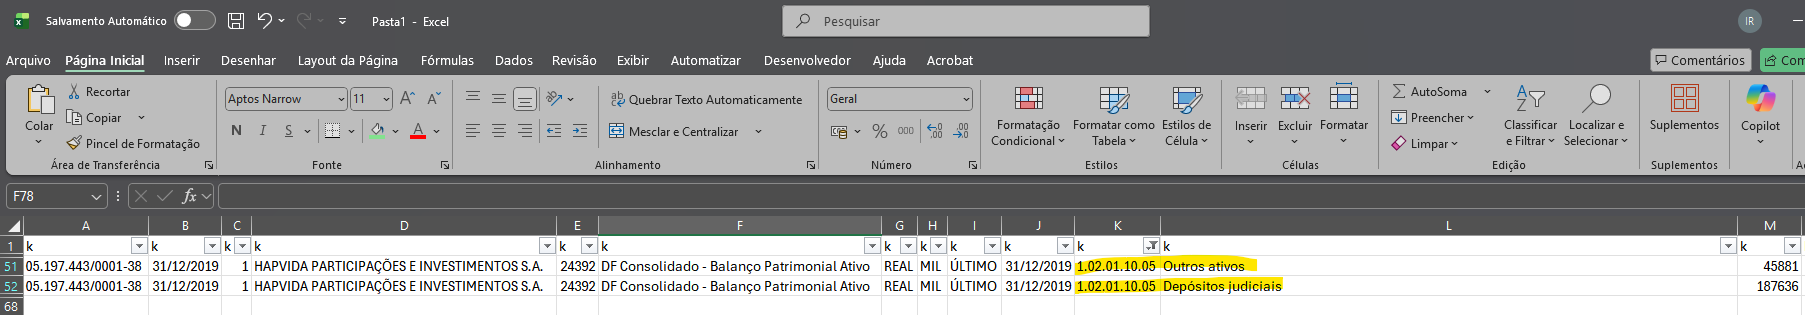

📋 Schema Alvo Final: Tabelas Harmonizadas (Golden Schema)

Abaixo está a definição da estrutura unificada para as tabelas da camada Silver (`BP`, `DRE`, `DFC`). O objetivo deste schema é permitir o empilhamento (`UNION ALL`) e a criação de uma dimensão temporal e de entidade consistentes para Business Intelligence.

| Grupo | Coluna | Tipo | Descrição / Racional |
| :--- | :--- | :--- | :--- |
| **Chaves** | `CNPJ_CIA` | Texto | Chave primária da entidade (CNPJ). |
| | `DT_REFER` | Data | Data de corte do balanço. Fundamental para *Time Intelligence*. |
| | `CD_CONTA` | Texto | Código contábil (Ex: `6.01`). É o ID único da linha no demonstrativo. |
| **Entidade** | `DENOM_CIA` | Texto | Razão social / Nome da empresa. |
| | `CD_CVM` | Int | Código CVM (usado para joins com dados de mercado/ações). |
| | `SETOR_ATIV` | Texto | Setor de atividade econômica na B3. |
| **Tempo** | `DT_REFER_TRATADO` | Date | Versão "Data Pura" (sem hora) do `DT_REFER`. |
| | `DT_REFER_ANO` | Int | Ano (ex: 2021, 2022) para filtros rápidos e particionamento. |
| | `DT_FIM_EXERC_TRATADO`| Date | Data de fim do exercício fiscal (útil para empresas com ano fiscal deslocado). |
| | `DT_FIM_EXERC_ANO` | Int | Ano do exercício fiscal. |
| | `VERSAO` | Int | Versão do documento entregue à CVM (1, 2...). |
| **Negócio** | `GRUPO_DFP_TRATADO` | Texto | Identificador do demonstrativo: `'BP'`, `'DRE'`, `'DFC'`. Chave do empilhamento. |
| | `VL_CONTA_TRATADO` | Float | Valor monetário unificado. Mesma escala e moeda para todas as linhas. |
| | `DS_CONTA` | Texto | Nome da conta **Curado/Padronizado** (Ex: "CAIXA E EQUIVALENTES"). |
| | `CONTA_NOME_COMPLETO` | Texto | Concatenação `CD_CONTA` + `DS_CONTA`. Ideal para eixos de gráficos. |
| | `CD_CONTA_QTD_DIGITOS`| Int | Nível hierárquico numérico da conta (1, 3, 5...). |
| | `ST_CONTA_FIXA` | Texto | `'S'` ou `'N'`. Indica se é uma conta fixa obrigatória da taxonomia CVM. |
| **Qualidade** | `DS_CONTA_REPORTADA` | Texto | Nome original vindo do CSV (Ex: "Variação monetária"). Vital para auditoria (Traceability). |
| **(Traceability)** | `ST_CONTA_FIXA_REPORTADA`| Texto | Status original da conta fixa vindo do arquivo bruto. |
| | `FLAG_NORMALIZACAO` | Bool | `True` se o nome da conta foi alterado/padronizado via *Golden Map*. |
| | `FLAG_RECONSTRUCAO` | Bool | `True` se o valor foi calculado via Python (*Safe Mode*) ou se a linha foi criada artificialmente. |
| | `STATUS_MATH` | Texto | Status da validação contábil: `'OK'`, `'DIVERGENTE'` ou `'DESBALANCEADO'`. |
| **Estrutura** | `IS_LEAF` | Bool | Indica se é o último nível (analítico). Útil para evitar soma duplicada em BI. |
| | `DS_NIVEL_1` ... `5` | Texto | Colunas de hierarquia para *Drill-Down* visual e matrizes. |
| **Metadados** | `_origem_tabela` | Texto | Nome da tabela da camada Bronze de onde o dado foi extraído. |

In [20]:
df_bp_silver.columns

Index(['CNPJ_CIA', 'SETOR_ATIV', 'DT_REFER', 'DT_REFER_TRATADO',
       'DT_REFER_ANO', 'VERSAO', 'DENOM_CIA', 'CD_CVM', 'GRUPO_DFP_TRATADO',
       'DT_FIM_EXERC_TRATADO', 'DT_FIM_EXERC_ANO', 'CD_CONTA',
       'CD_CONTA_QTD_DIGITOS', 'DS_CONTA', 'DS_CONTA_REPORTADA',
       'FLAG_NORMALIZACAO', 'FLAG_RECONSTRUCAO', 'STATUS_MATH',
       'CONTA_NOME_COMPLETO', 'VL_CONTA_TRATADO', 'ST_CONTA_FIXA',
       'ST_CONTA_FIXA_REPORTADA', 'IS_LEAF', 'DS_NIVEL_1', 'DS_NIVEL_2',
       'DS_NIVEL_3', 'DS_NIVEL_4', 'DS_NIVEL_5', '_origem_tabela'],
      dtype='object')

## 6. Escrita na Camada Silver — `n1_dfp_cia_aberta_bp`

In [21]:
# Filtra apenas as linhas onde NÃO EXISTIA descrição original (ou seja, foram criadas/reconstruídas)
linhas_criadas = df_bp_silver[
    (df_bp_silver['DS_CONTA_REPORTADA'].isna()) & 
    (df_bp_silver['FLAG_RECONSTRUCAO'] == True)
]

print(f"Quantidade de Linhas Criadas pelo Pipeline: {len(linhas_criadas)}")
print("\nExemplo das linhas fantasmas que salvamos:")
print(linhas_criadas[['CNPJ_CIA', 'DT_REFER', 'CD_CONTA', 'DS_CONTA', 'VL_CONTA_TRATADO']].head())

Quantidade de Linhas Criadas pelo Pipeline: 24

Exemplo das linhas fantasmas que salvamos:
                  CNPJ_CIA   DT_REFER    CD_CONTA  \
180437  10.760.260/0001-19 2021-12-31  1.02.04.01   
180438  17.314.329/0001-20 2021-12-31  1.01.03.02   
180439  33.041.260/0652-90 2022-12-31  2.01.02.01   
180440  47.508.411/0001-56 2022-12-31  2.01.02.01   
180441  60.933.603/0001-78 2022-12-31  2.01.03.01   

                           DS_CONTA  VL_CONTA_TRATADO  
180437                  INTANGÍVEIS      1.108119e+09  
180438      OUTRAS CONTAS A RECEBER      1.568000e+06  
180439       FORNECEDORES NACIONAIS      7.908000e+09  
180440       FORNECEDORES NACIONAIS      3.123000e+09  
180441  OBRIGAÇÕES FISCAIS FEDERAIS      3.315500e+07  


In [22]:
df_bp_silver.to_sql(
            name='n1_dfp_cia_aberta_bp',
            schema='layer_02_silver',
            con=engine,
            if_exists='replace',
            index=False,
            chunksize=10000, # Otimização para escrita em lotes
            method='multi'   # Otimização para insert múltiplo (dependendo do DB, pode ser removido)
        )

180461